In [21]:
import sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tsfm_public import (
    TinyTimeMixerForPrediction,
    TimeSeriesPreprocessor,
    TimeSeriesForecastingPipeline,
)

warnings.filterwarnings("ignore")
%matplotlib inline
print("torch:", torch.__version__, "  cuda:", torch.cuda.is_available())

torch: 2.10.0+cu128   cuda: False


In [22]:
DB_PATH         = "../SenSa/db.sqlite3"
DEVICE_ID       = "sensor_01"
METRIC          = "co"
RESAMPLE        = "1min"
CONTEXT_LENGTH  = 512
FORECAST_LENGTH = 96
HF_MODEL        = "ibm-granite/granite-timeseries-ttm-r2"

CAUTION = 25.0
DANGER  = 200.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


In [23]:
con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(f"""
    SELECT s.timestamp, s.{METRIC}
    FROM devices_sensordata s
    JOIN devices_device d ON d.id = s.device_id
    WHERE d.device_id = '{DEVICE_ID}' AND s.{METRIC} IS NOT NULL
    ORDER BY s.timestamp ASC
""", con, parse_dates=["timestamp"])
con.close()
print(f"loaded {len(df)} rows")
df.head()

loaded 8508 rows


,timestamp,co
0,2026-04-27 06:24:45.310546,12.70
1,2026-04-27 06:24:46.746011,12.95
2,2026-04-27 06:24:48.401677,12.01
3,2026-04-27 06:24:50.244724,9.91
4,2026-04-27 06:24:52.127435,9.72


In [24]:
df = (df.set_index("timestamp")
        .resample(RESAMPLE).mean()
        .interpolate("linear")
        .dropna()
        .reset_index())
df["series_id"] = DEVICE_ID
print(f"resampled to {RESAMPLE}: {len(df)} rows")
print(f"range: {df['timestamp'].min()} ~ {df['timestamp'].max()}")

assert len(df) >= CONTEXT_LENGTH + FORECAST_LENGTH, "데이터 부족"
df.tail()

resampled to 1min: 12939 rows
range: 2026-04-27 06:24:00 ~ 2026-05-06 06:02:00


,timestamp,co,series_id
12934,2026-05-06 05:58:00,12.039915,sensor_01
12935,2026-05-06 05:59:00,12.034871,sensor_01
12936,2026-05-06 06:00:00,12.029827,sensor_01
12937,2026-05-06 06:01:00,12.024783,sensor_01
12938,2026-05-06 06:02:00,14.269091,sensor_01


In [34]:
# spike 구간에 대해 forecast 다시 수행
forecast = pipeline(test_input)

pred_col = f"{METRIC}_prediction"
preds    = np.asarray(forecast[pred_col].iloc[0], dtype=float)
actuals  = test_target[METRIC].values
ts       = test_target["timestamp"].values

print(f"actuals max: {actuals.max():.2f}")
print(f"preds   max: {preds.max():.2f}")
print(f"forecast: {len(preds)} steps")

INFO:p-47062:t-137071387545728:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_token': None, 'id_columns': ['series_id'], 'timestamp_column': 'timestamp', 'target_columns': ['co'], 'observable_columns': [], 'control_columns': [], 'conditional_columns': [], 'categorical_columns': [], 'static_categorical_columns': []}


actuals max: 98.61
preds   max: 157.59
forecast: 96 steps


In [35]:
tsp = TimeSeriesPreprocessor(
    timestamp_column="timestamp",
    id_columns=["series_id"],
    target_columns=[METRIC],
    context_length=CONTEXT_LENGTH,
    prediction_length=FORECAST_LENGTH,
    scaling=True,
    scaler_type="standard",
)
tsp.train(df)
print("preprocessor ready")

preprocessor ready


In [36]:
model = TinyTimeMixerForPrediction.from_pretrained(HF_MODEL).to(DEVICE).eval()
print(f"loaded {HF_MODEL}")

loaded ibm-granite/granite-timeseries-ttm-r2


In [37]:
# spike가 포함된 구간으로 변경
spike_time = pd.Timestamp("2026-05-06 02:00:00")
df_idx = df.reset_index(drop=True)
spike_idx = df_idx[df_idx["timestamp"] >= spike_time].index[0]

start = max(0, spike_idx - CONTEXT_LENGTH)
end   = min(len(df_idx), spike_idx + FORECAST_LENGTH)

test_input  = df_idx.iloc[start : start + CONTEXT_LENGTH].copy()
test_target = df_idx.iloc[start + CONTEXT_LENGTH : end].copy()

print(f"test_target range: {test_target['timestamp'].min()} ~ {test_target['timestamp'].max()}")
print(f"test_target max value: {test_target[METRIC].max():.2f}")

test_target range: 2026-05-06 02:00:00 ~ 2026-05-06 03:35:00
test_target max value: 98.61


In [38]:
# 잔차 기본 통계
residuals          = actuals - preds
residuals_centered = residuals - residuals.mean()
thresh             = 4 * np.std(residuals_centered)

# 보조 로직 1: 잔차 절대값 임계
RESIDUAL_ABSOLUTE_LIMIT = 20.0

# 보조 로직 2: forecast 사전 경고
forecast_exceed_count = (preds >= CAUTION).sum()
forecast_warning      = forecast_exceed_count >= 10

# 최종 anomaly 판정
anomaly = (
    (np.abs(residuals_centered) > thresh) |
    (np.abs(residuals) > RESIDUAL_ABSOLUTE_LIMIT) |
    (actuals >= CAUTION)
)

print(f"residual mean (bias): {residuals.mean():.2f}")
print(f"residual std:         {np.std(residuals_centered):.2f}")
print(f"residual abs max:     {np.max(np.abs(residuals)):.2f}")
print(f"anomaly count:        {anomaly.sum()} / {len(anomaly)}")
print()
print(f"forecast exceeds caution: {forecast_exceed_count} / {len(preds)} steps")
if forecast_warning:
    print(f"⚠️  TTM 사전 경고: 향후 {forecast_exceed_count}분 caution 초과 예상")
else:
    print(f"✅ 사전 경고 없음")

residual mean (bias): -108.50
residual std:         39.43
residual abs max:     144.83
anomaly count:        96 / 96

forecast exceeds caution: 96 / 96 steps
⚠️  TTM 사전 경고: 향후 96분 caution 초과 예상


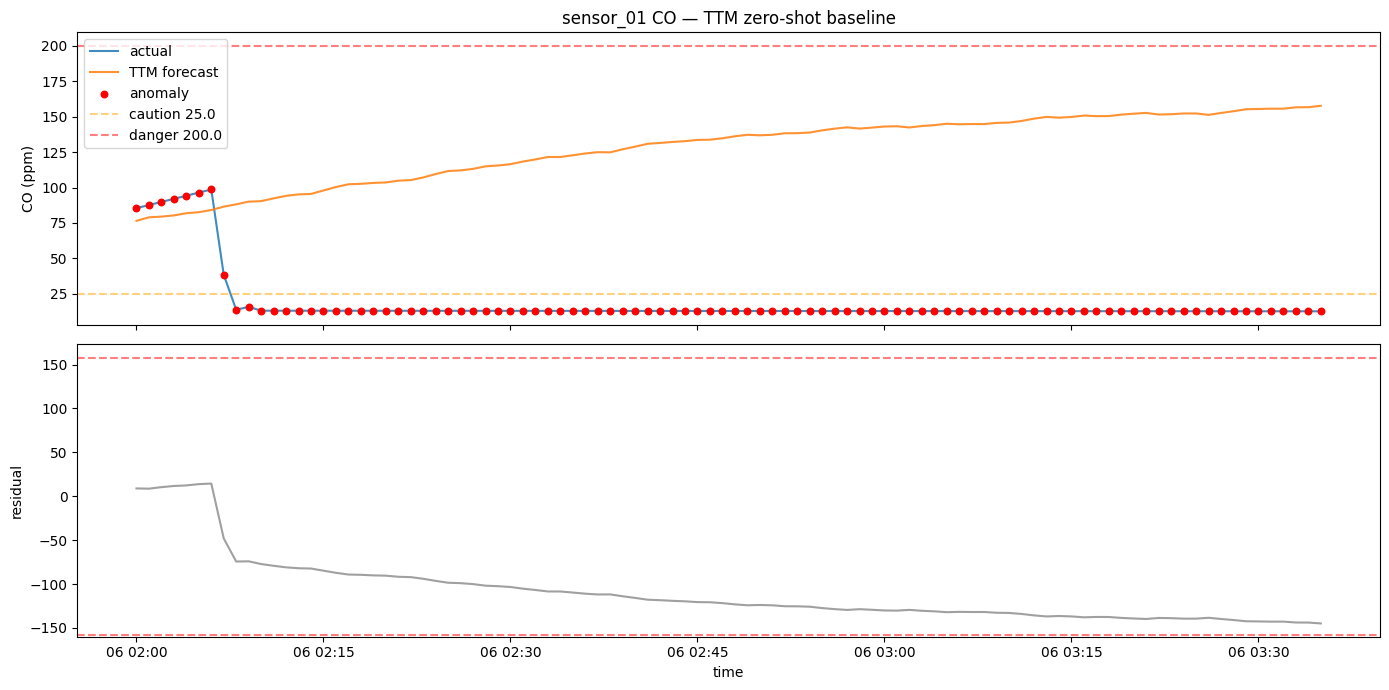

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(ts, actuals, label="actual",       color="#1f77b4", alpha=0.85)
ax.plot(ts, preds,   label="TTM forecast", color="#ff7f0e", alpha=0.85, linewidth=1.5)
ax.scatter(ts[anomaly], actuals[anomaly], color="red", s=22, zorder=5, label="anomaly")
ax.axhline(CAUTION, color="orange", ls="--", alpha=0.5, label=f"caution {CAUTION}")
ax.axhline(DANGER,  color="red",    ls="--", alpha=0.5, label=f"danger {DANGER}")
ax.set_ylabel(f"{METRIC.upper()} (ppm)")
ax.set_title(f"{DEVICE_ID} {METRIC.upper()} — TTM zero-shot baseline")
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(ts, residuals, color="gray", alpha=0.75)
ax.axhline( thresh, color="red", ls="--", alpha=0.5)
ax.axhline(-thresh, color="red", ls="--", alpha=0.5)
ax.set_ylabel("residual"); ax.set_xlabel("time")

plt.tight_layout()
plt.savefig("ttm_baseline.png", dpi=110)
plt.show()

In [40]:
residuals = actuals - preds
residuals_centered = residuals - residuals.mean()   # bias 제거
thresh = 4 * np.std(residuals_centered)             # 3σ → 4σ
anomaly = (np.abs(residuals_centered) > thresh) | (actuals >= CAUTION)

print(f"residual mean (bias): {residuals.mean():.2f}")
print(f"residual std:         {np.std(residuals_centered):.2f}")
print(f"anomaly:              {anomaly.sum()} / {len(anomaly)}")

residual mean (bias): -108.50
residual std:         39.43
anomaly:              8 / 96


In [41]:
# 마지막 구간 대신, spike가 포함된 특정 시점 선택
# (이전 ARIMA에서 05-06 02시경 spike가 있었음)
spike_time = pd.Timestamp("2026-05-06 02:00:00")
spike_idx = df[df["timestamp"] >= spike_time].index[0]

start = spike_idx - CONTEXT_LENGTH
end   = spike_idx + FORECAST_LENGTH
test_input  = df.iloc[start:start+CONTEXT_LENGTH].copy()
test_target = df.iloc[start+CONTEXT_LENGTH:end].copy()

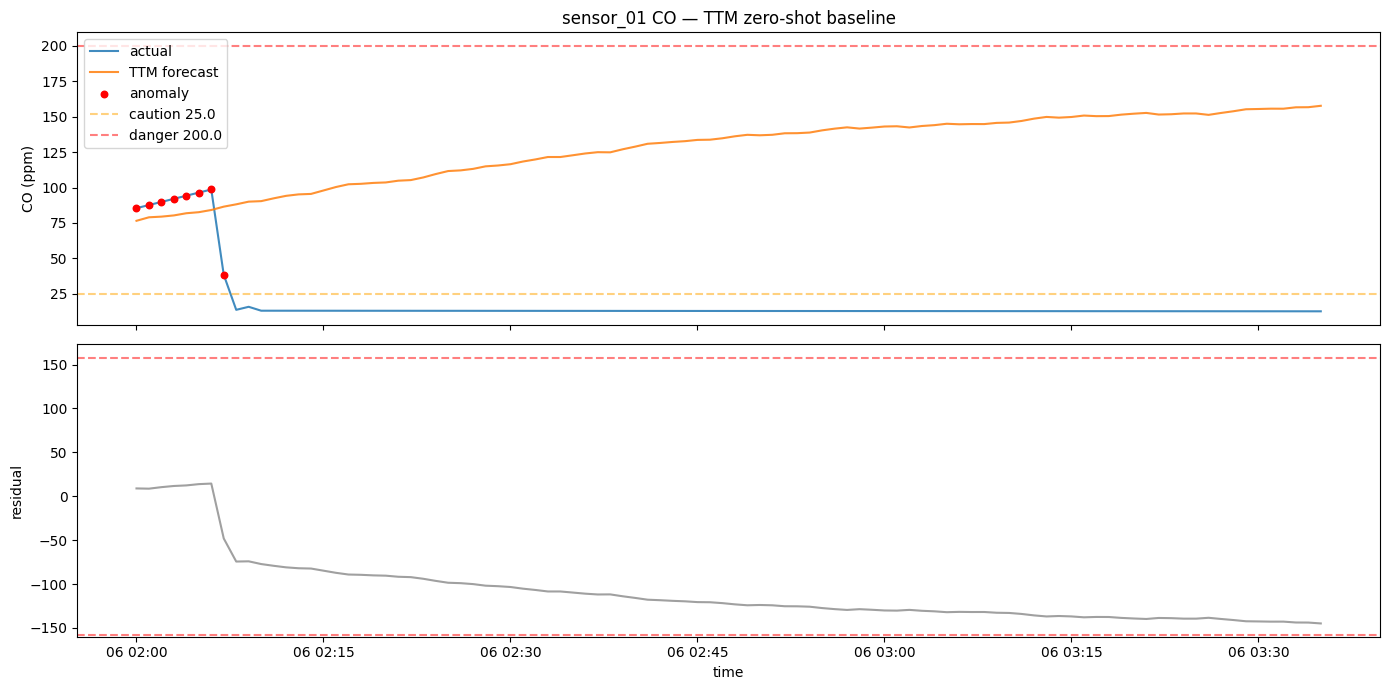

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(ts, actuals, label="actual",       color="#1f77b4", alpha=0.85)
ax.plot(ts, preds,   label="TTM forecast", color="#ff7f0e", alpha=0.85, linewidth=1.5)
ax.scatter(ts[anomaly], actuals[anomaly], color="red", s=22, zorder=5, label="anomaly")
ax.axhline(CAUTION, color="orange", ls="--", alpha=0.5, label=f"caution {CAUTION}")
ax.axhline(DANGER,  color="red",    ls="--", alpha=0.5, label=f"danger {DANGER}")
ax.set_ylabel(f"{METRIC.upper()} (ppm)")
ax.set_title(f"{DEVICE_ID} {METRIC.upper()} — TTM zero-shot baseline")
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(ts, residuals, color="gray", alpha=0.75)
ax.axhline( thresh, color="red", ls="--", alpha=0.5)
ax.axhline(-thresh, color="red", ls="--", alpha=0.5)
ax.set_ylabel("residual"); ax.set_xlabel("time")

plt.tight_layout()
plt.savefig("ttm_baseline.png", dpi=110)
plt.show()